<a href="https://colab.research.google.com/github/Subashinimuralikrishnan/Chronic-Kidney-Disease-Prediction/blob/main/Quantum_Boosted_ML_CKD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px #plots especially for eda
import warnings as w
w.filterwarnings('ignore')

plt.style.use('fivethirtyeight') #standard design for plots
%matplotlib inline
#for inline view of plots
pd.set_option('display.max_columns',26)

In [ ]:
df=pd.read_csv('./kidney_disease.csv')
df.head()#top5 rows

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


In [ ]:
df.drop('id',axis=1,inplace=True)
df

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,49.0,0.5,150.0,4.9,15.7,47,6700,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,31.0,1.2,141.0,3.5,16.5,54,7800,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,26.0,0.6,137.0,4.4,15.8,49,6600,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,50.0,1.0,135.0,4.9,14.2,51,7200,5.9,no,no,no,good,no,no,notckd


In [ ]:
df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'aanemia', 'class']
df

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,49.0,0.5,150.0,4.9,15.7,47,6700,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,31.0,1.2,141.0,3.5,16.5,54,7800,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,26.0,0.6,137.0,4.4,15.8,49,6600,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,50.0,1.0,135.0,4.9,14.2,51,7200,5.9,no,no,no,good,no,no,notckd


In [ ]:
df.describe()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


As we can see that all columns are not displayed since they are not in nummerical format, We need to change them into numerical data type to get all features as numerical for computations

In [ ]:
df['packed_cell_volume'] = pd.to_numeric(df['packed_cell_volume'], errors='coerce')
df['white_blood_cell_count'] = pd.to_numeric(df['white_blood_cell_count'], errors='coerce')
df['red_blood_cell_count'] = pd.to_numeric(df['red_blood_cell_count'], errors='coerce')
df['age'].dtype


dtype('float64')

In [ ]:
df.describe()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.000000,294.000000,269.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,2944.474190,1.025323
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.000000,8000.000000,4.800000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


**Changed to Numerical Values**
As we can see that after converting to numerical data type, now the analysis of the specific column is displayed

In [ ]:
obj_cols=[c for c in df.columns if df[c].dtype=='object']
num_cols=[c for c in df.columns if df[c].dtype!='object']

seperating the objects and numericals to seperate lists


In [ ]:
for col in obj_cols:
    print(f"{col} has {df[col].unique()} values\n")

red_blood_cells has [nan 'normal' 'abnormal'] values

pus_cell has ['normal' 'abnormal' nan] values

pus_cell_clumps has ['notpresent' 'present' nan] values

bacteria has ['notpresent' 'present' nan] values

hypertension has ['yes' 'no' nan] values

diabetes_mellitus has ['yes' 'no' ' yes' '\tno' '\tyes' nan] values

coronary_artery_disease has ['no' 'yes' '\tno' nan] values

appetite has ['good' 'poor' nan] values

peda_edema has ['no' 'yes' nan] values

aanemia has ['no' 'yes' nan] values

class has ['ckd' 'ckd\t' 'notckd'] values



In [ ]:
print([list(map(ord, x)) for x in df['class'].unique() if isinstance(x, str)])

[[99, 107, 100], [99, 107, 100, 9], [110, 111, 116, 99, 107, 100]]


displaying unique values


In [ ]:
df['diabetes_mellitus'].replace(to_replace = {'\tno':'no','\tyes':'yes',' yes':'yes'},inplace=True)

df['coronary_artery_disease'] = df['coronary_artery_disease'].replace(to_replace = '\tno', value='no')

df['class'] = df['class'].replace(to_replace = 'ckd\t',value='ckd')
df['class']=df['class'].replace(to_replace='notckd',value= 'not ckd')
df

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,49.0,0.5,150.0,4.9,15.7,47.0,6700.0,4.9,no,no,no,good,no,no,not ckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,31.0,1.2,141.0,3.5,16.5,54.0,7800.0,6.2,no,no,no,good,no,no,not ckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,26.0,0.6,137.0,4.4,15.8,49.0,6600.0,5.4,no,no,no,good,no,no,not ckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,50.0,1.0,135.0,4.9,14.2,51.0,7200.0,5.9,no,no,no,good,no,no,not ckd


In [ ]:
df['class']=df['class'].map({'ckd':0,'not ckd':1})
#df['class']=pd.to_numeric(df['class'],errors='coerce')
df['class'].unique()

array([0, 1])

**Changed the values of Output Parameters**


*   Chronic Kidney Disease(ckd) - 0
*   Not a Chronic Kidney Disease(nckd) - 1



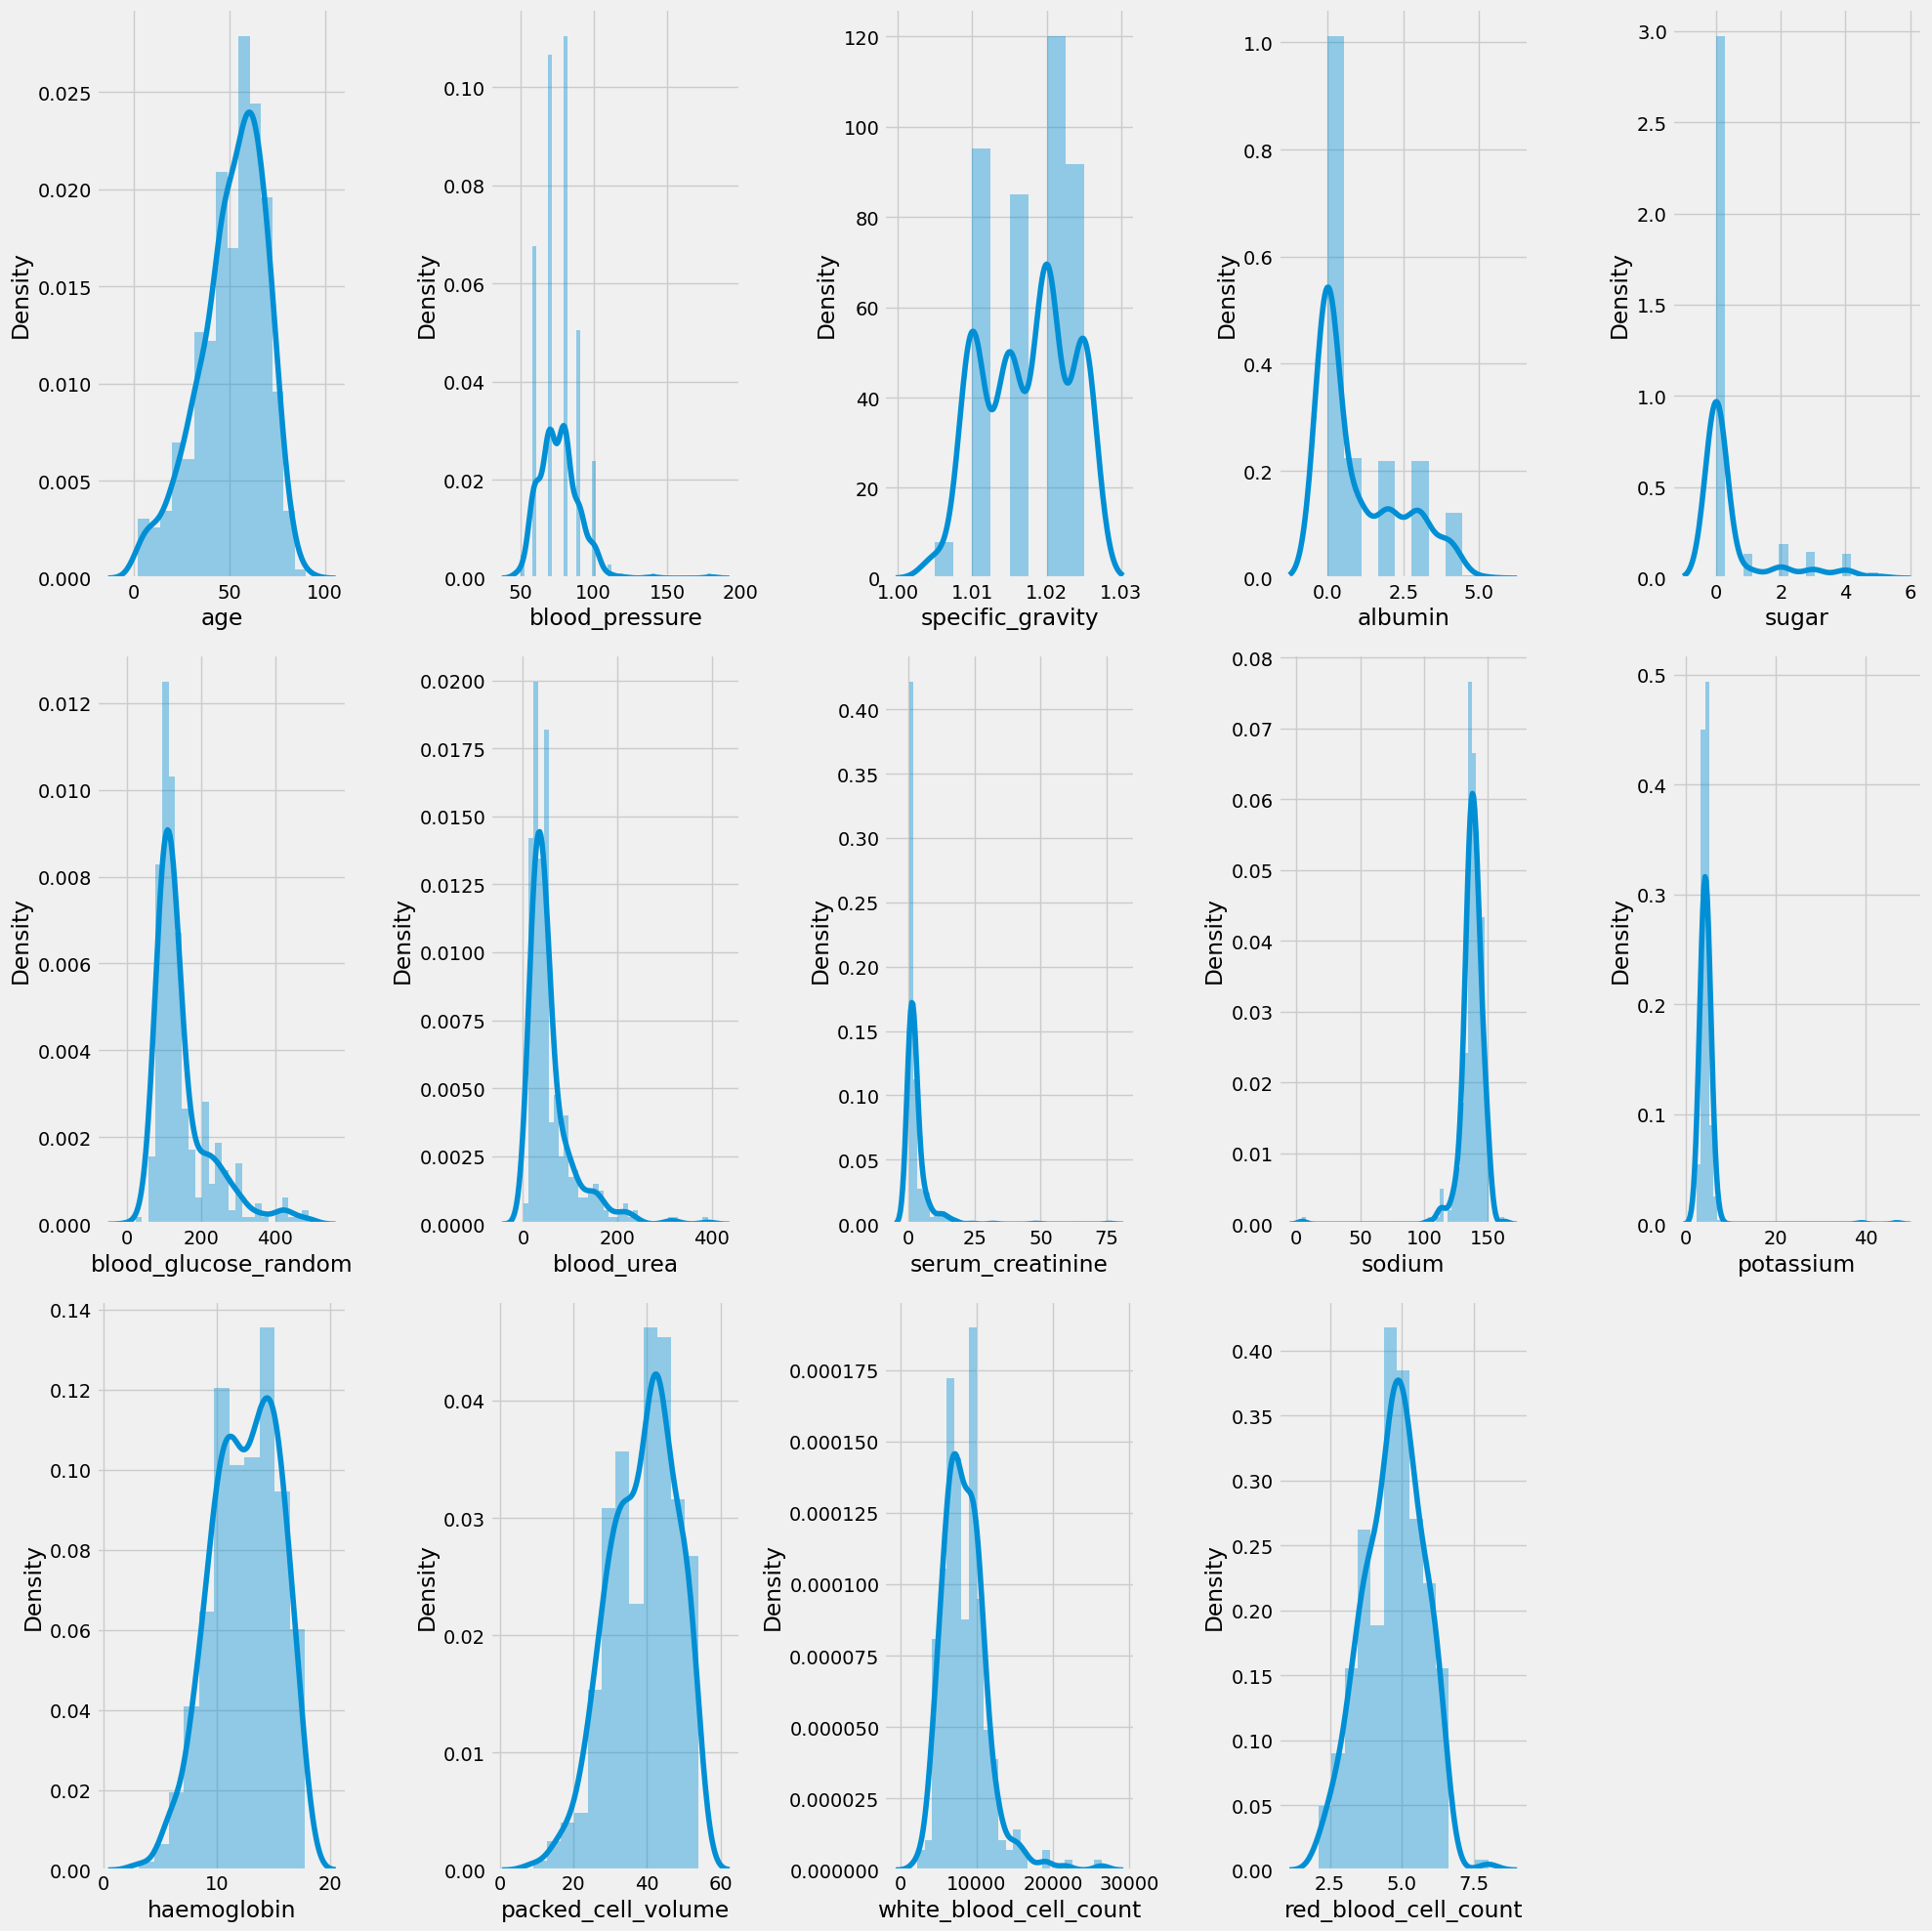

In [ ]:
plt.figure(figsize=(20,20)) #setting height width of figure
plotnum=1
for column in num_cols:
  ax=plt.subplot(3,5,plotnum) #5 colums and 3 rows for distribution of figures
  sns.distplot(df[column]) #distribution plot
  plt.xlabel(column) # adding column name as label
  plotnum+=1
plt.tight_layout()
plt.show()


**We have shown how well the data has been distributed:**


1.   Curved Line - shows the KDE (Kernel Density Estimate) Peaks show the dense values that are present.
2.   Histogram - shows the actual distribution.



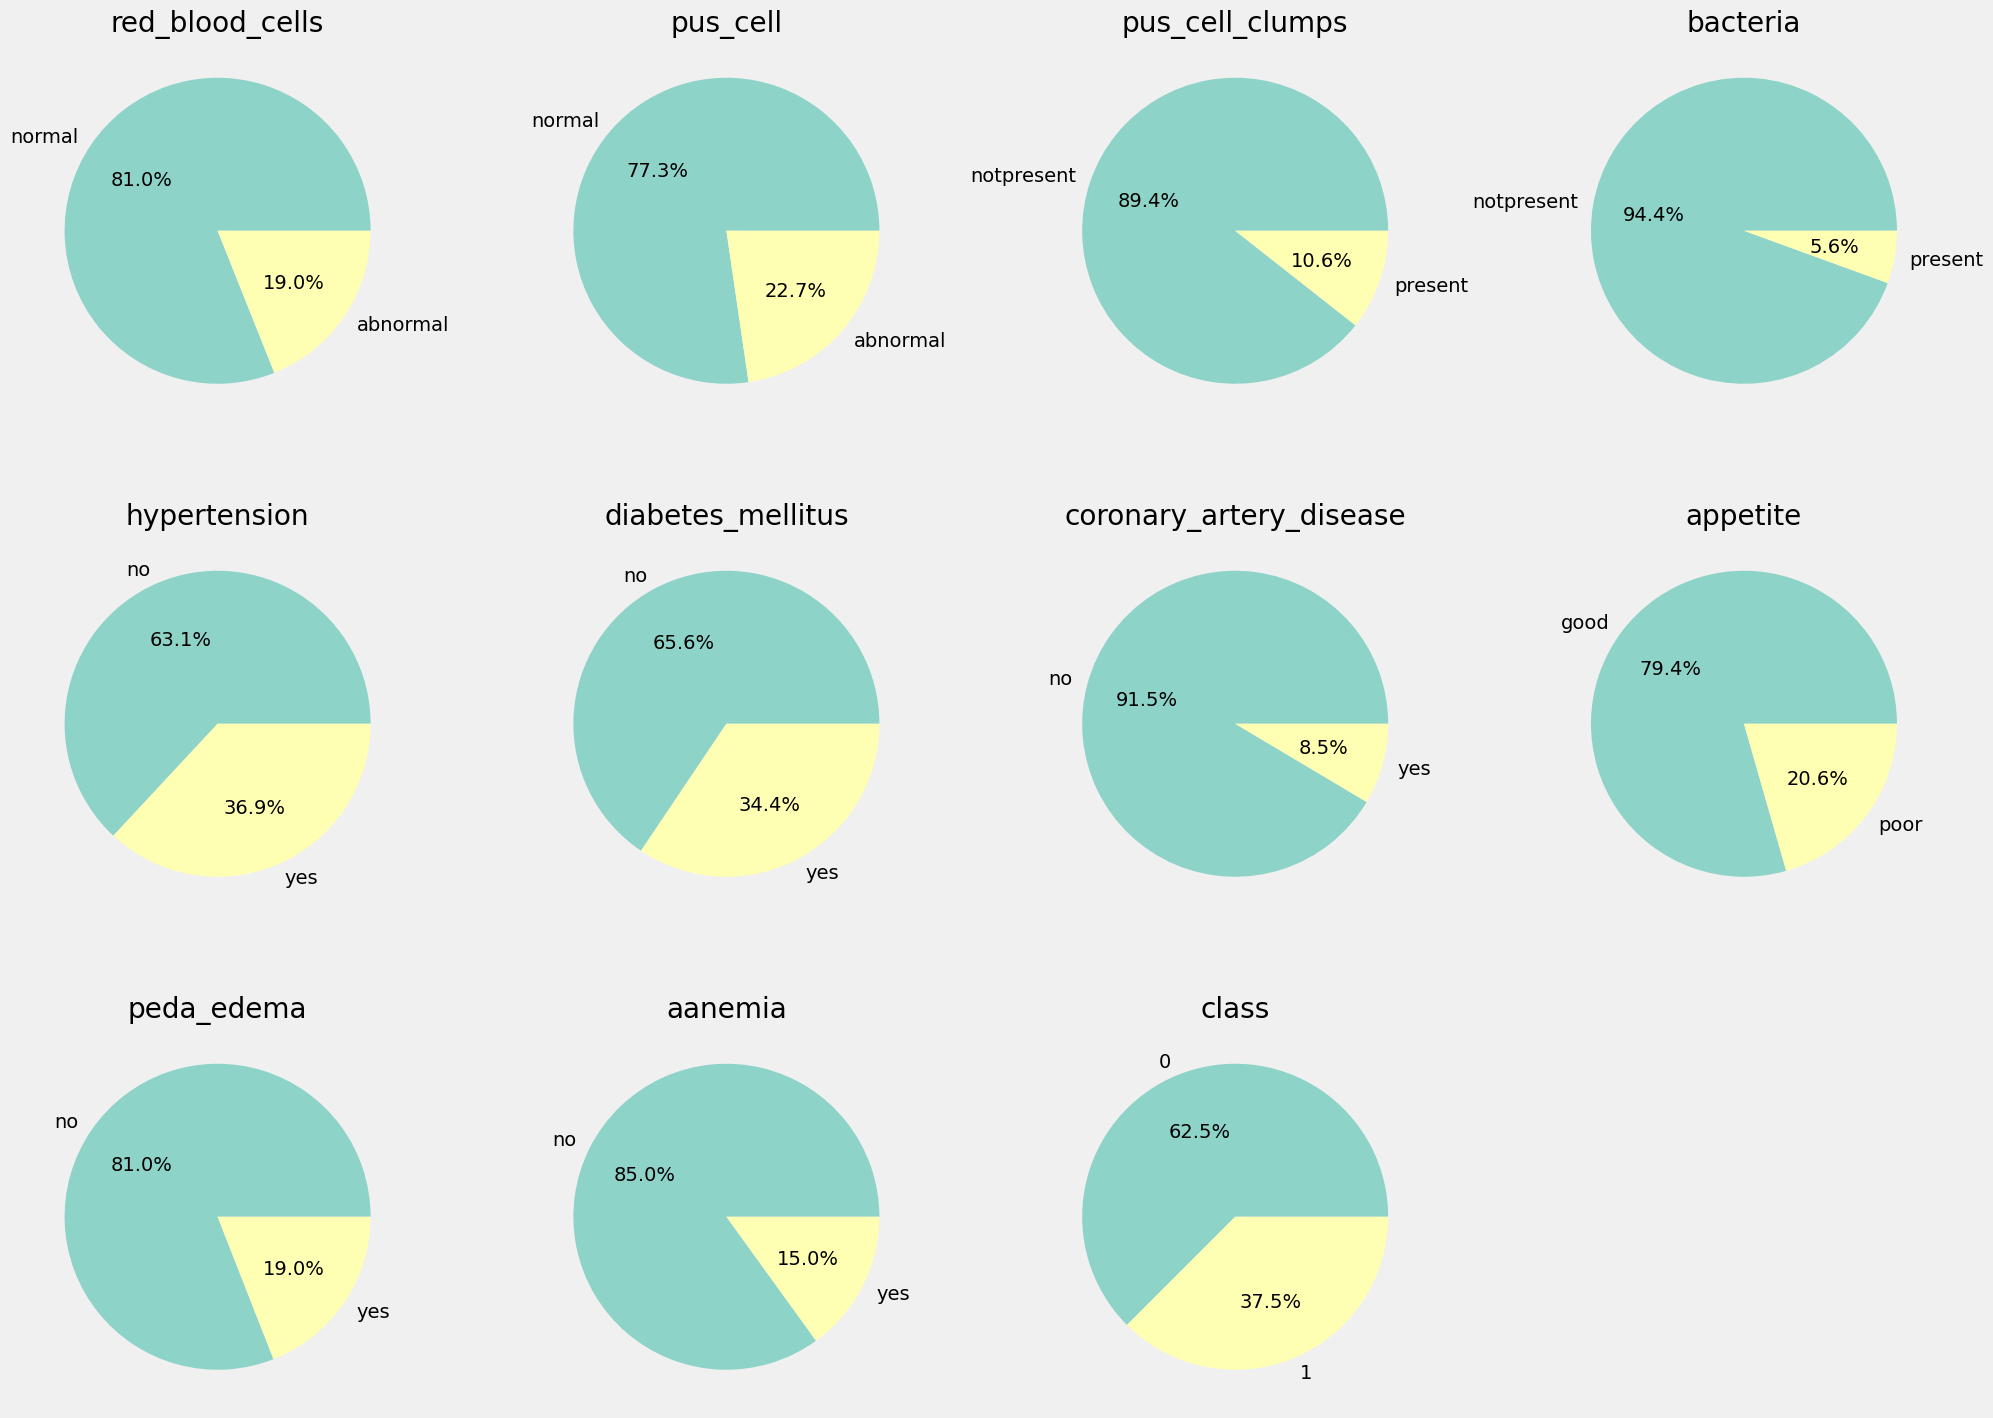

In [ ]:

plt.figure(figsize=(20, 15))  # Set figure size
plotnumber = 1

# Loop through each column in the object columns list
for c in obj_cols:
    if plotnumber <= 11:  # Limit the number of subplots
        # Convert to string type if necessary
        if df[c].dtype != 'object':
            df[c] = df[c].astype(str)

        # Calculate value counts for the pie chart
        value_counts = df[c].value_counts()

        # Define subplot grid
        ax = plt.subplot(3, 4, plotnumber)

        # Plot pie chart
        ax.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', colors=plt.cm.Set3(range(len(value_counts))))
        ax.set_title(c)  # Set the title for each subplot

        plotnumber += 1  # Increment subplot index

plt.tight_layout()  # Adjust layout
plt.show()  # Display all pie charts


In [ ]:
df['class']=pd.to_numeric(df['class'],errors='coerce')
num_cols.append('class')

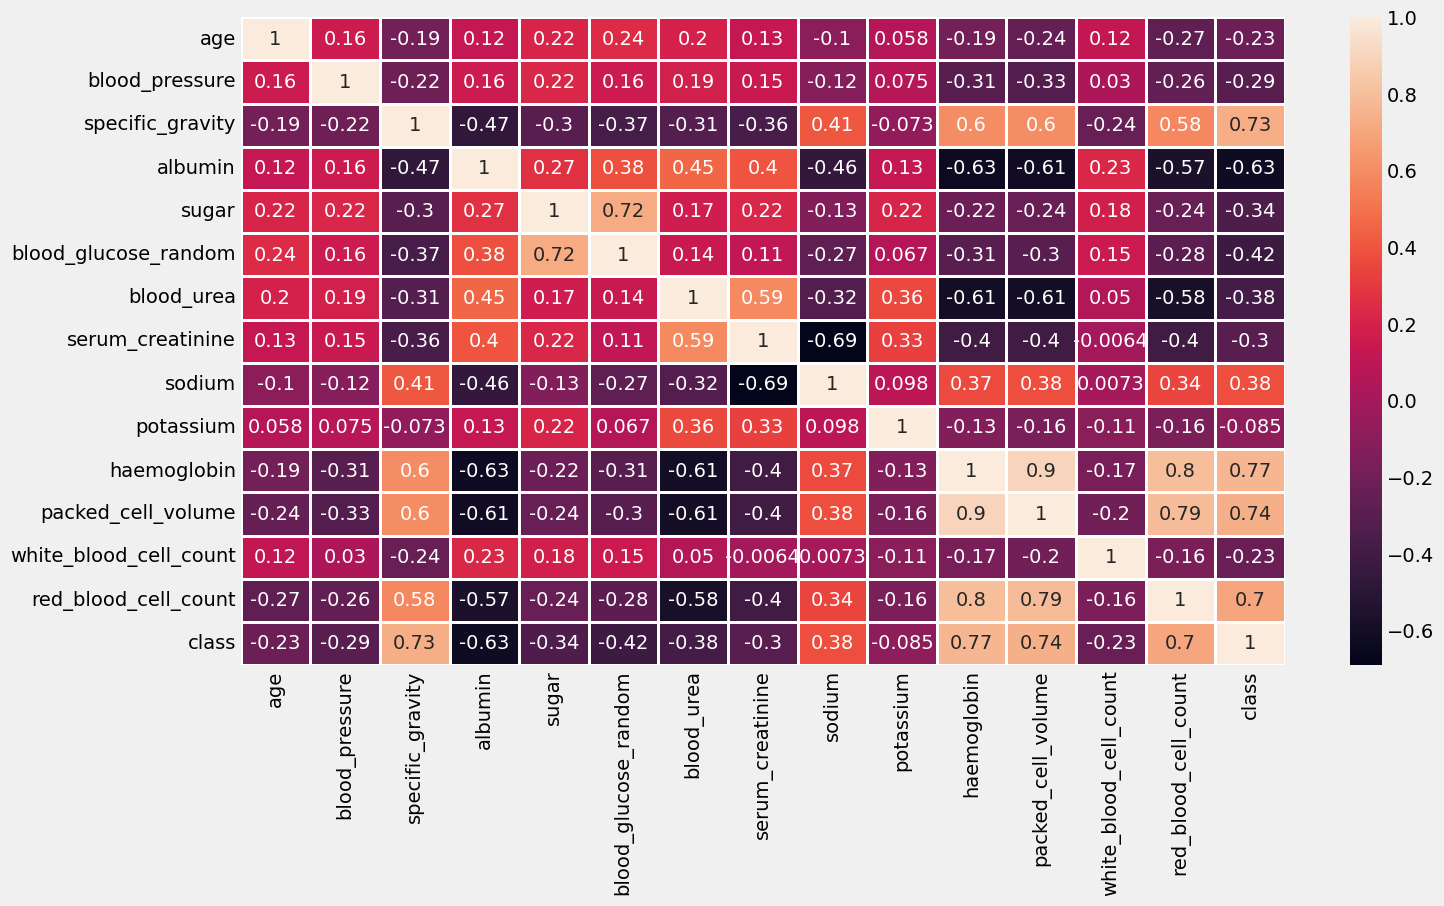

In [ ]:
plt.figure(figsize=(15,8))
sns.heatmap(df[num_cols].corr(),annot=True,linewidths=2,linecolor='white')
plt.show()

In [ ]:
def kde(col):
  grid=sns.FacetGrid(df,hue="class",height=6,aspect=2)
  grid.map(sns.kdeplot,col)
  grid.add_legend()


In [ ]:
def scatter(col1,col2):
  fig = px.scatter(df,x=col1,y=col2,color="class",template="presentation")
  return fig.show()


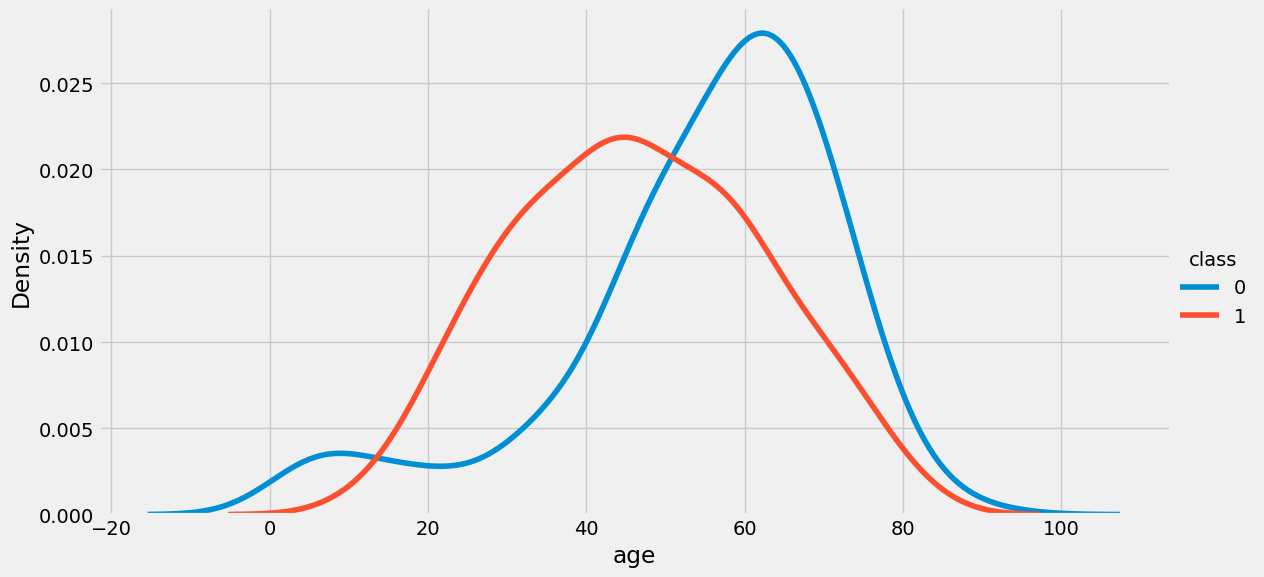

In [ ]:
kde(num_cols[0])

In [ ]:
scatter(num_cols[1],num_cols[2])

In [ ]:
px.bar(df,x="blood_pressure",y="haemoglobin",color="class",barmode='group',template="presentation",height=400)

In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
red_blood_cells,152
red_blood_cell_count,131
white_blood_cell_count,106
potassium,88
sodium,87
packed_cell_volume,71
pus_cell,65
haemoglobin,52
sugar,49
specific_gravity,47


In [ ]:

df[num_cols].isna().sum()

,0
age,9
blood_pressure,12
specific_gravity,47
albumin,46
sugar,49
blood_glucose_random,44
blood_urea,19
serum_creatinine,17
sodium,87
potassium,88


In [ ]:
df[obj_cols].isna().sum()

,0
red_blood_cells,152
pus_cell,65
pus_cell_clumps,4
bacteria,4
hypertension,2
diabetes_mellitus,2
coronary_artery_disease,2
appetite,1
peda_edema,1
aanemia,1


In [ ]:
def random_input(col):
    ran_sample = df[col].dropna().sample(df[col].isna().sum())
    ran_sample.index = df[df[col].isnull()].index
    df.loc[df[col].isnull(),col]=ran_sample
def impute_mode(col):
    mode = df[col].mode()[0]
    df[col]=df[col].fillna(mode)
for col in num_cols:
  random_input(col)
df[num_cols].isna().sum()

,0
age,0
blood_pressure,0
specific_gravity,0
albumin,0
sugar,0
blood_glucose_random,0
blood_urea,0
serum_creatinine,0
sodium,0
potassium,0


In [ ]:
random_input('red_blood_cells')
random_input('pus_cell')
for col in obj_cols:
  impute_mode(col)
df[obj_cols].isna().sum()

,0
red_blood_cells,0
pus_cell,0
pus_cell_clumps,0
bacteria,0
hypertension,0
diabetes_mellitus,0
coronary_artery_disease,0
appetite,0
peda_edema,0
aanemia,0


In [ ]:
for col in obj_cols:
  print(f"{col} has {len(df[col].unique())} values\n")

red_blood_cells has 2 values

pus_cell has 2 values

pus_cell_clumps has 2 values

bacteria has 2 values

hypertension has 2 values

diabetes_mellitus has 2 values

coronary_artery_disease has 2 values

appetite has 2 values

peda_edema has 2 values

aanemia has 2 values

class has 2 values



In [ ]:
from sklearn.preprocessing import LabelEncoder #encodng strings to some values
mycoder=LabelEncoder()
for col in obj_cols:
  df[col]=mycoder.fit_transform(df[col]) #fits the encoder to unique values and then transforms the values
df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,36.0,1.2,142.0,4.5,15.4,44.0,7800.0,5.2,1,1,0,0,0,0,0
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,100.0,18.0,0.8,136.0,3.9,11.3,38.0,6000.0,5.3,0,0,0,0,0,0,0
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,53.0,1.8,146.0,4.0,9.6,31.0,7500.0,4.5,0,1,0,1,0,1,0
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,1,0,0,1,1,1,0
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,26.0,1.4,147.0,5.0,11.6,35.0,7300.0,4.6,0,0,0,0,0,0,0


In [ ]:
inp_col=[]
for col in df.columns:
  if col!='class':
    inp_col.append(col) # storing independent columns in the list
out_col='class'
x=df[inp_col]
y=df[out_col]

In [ ]:
from sklearn.model_selection import train_test_split
X_train,x_test,Y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=0)


In [ ]:
class LogisticRegression():
  def __init__(self,lr=0.001,num_of_iters=10000):
    self.lr=lr
    self.num_of_iters=num_of_iters
    self.w=None
    self.b=None
  def sigmoid(self,pred):
    return (1/(1+np.exp(-pred)))
  def fit(self,X,y):
    no_of_samples,n_features=X.shape
    self.w=np.zeros(n_features)
    self.b=0

    for i in range(self.num_of_iters):
      y_cap_temp=np.dot(X,self.w)+self.b
      y_cap=self.sigmoid(y_cap_temp)
      dw=(1/no_of_samples)*np.dot(X.T,(y_cap-y))
      db=(1/(no_of_samples))*np.sum(y_cap-y)
      self.w=self.w-self.lr*dw
      self.b=self.b-self.lr*db
  def predict(self,x):
    y_pred_temp=np.dot(x,self.w)+self.b
    y_pred=self.sigmoid(y_pred_temp)
    class_predict=[]
    for i in y_pred:
      if i<=0.5:
        class_predict.append(0)
      else:
        class_predict.append(1)
    return class_predict

In [ ]:
lg=LogisticRegression(lr=0.01)
lg.fit(X_train,Y_train)
predicted_y=lg.predict(x_test)
print(len(predicted_y))
print(y_test.shape)
lg_acc=np.sum(predicted_y==y_test)/len(y_test)
print("Logistic Regression- Accuracy:",lg_acc)

120
(120,)
Logistic Regression- Accuracy: 0.75


In [ ]:
class Node():
  def __init__(self,feature_index=None,threshold=None,left=None,right=None,ig=None,value=None):
    self.feature_index=feature_index
    self.threshold=threshold
    self.left=left
    self.right=right
    self.ig=ig
    self.value=value


In [ ]:

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=.3, random_state=0)


In [ ]:
!pip install catboost

In [ ]:

from catboost import CatBoostClassifier
cat=CatBoostClassifier(iterations=20,random_seed=42)
cat.fit(X_train,Y_train)
cat_predicted_y=cat.predict(X_test)
cat_acc=accuracy_score(Y_test,cat_predicted_y)
print(f"CatBoost Accuracy:{cat_acc}")

Learning rate set to 0.216185
0:	learn: 0.4296352	total: 7.96ms	remaining: 151ms
1:	learn: 0.3007198	total: 11.1ms	remaining: 99.8ms
2:	learn: 0.1906648	total: 13ms	remaining: 73.7ms
3:	learn: 0.1381877	total: 18.4ms	remaining: 73.6ms
4:	learn: 0.0998696	total: 20.8ms	remaining: 62.3ms
5:	learn: 0.0810090	total: 24.7ms	remaining: 57.6ms
6:	learn: 0.0714957	total: 26.5ms	remaining: 49.2ms
7:	learn: 0.0623948	total: 28.4ms	remaining: 42.7ms
8:	learn: 0.0548185	total: 30.5ms	remaining: 37.3ms
9:	learn: 0.0456066	total: 32.3ms	remaining: 32.3ms
10:	learn: 0.0371729	total: 34.3ms	remaining: 28ms
11:	learn: 0.0319555	total: 36.2ms	remaining: 24.1ms
12:	learn: 0.0282545	total: 38ms	remaining: 20.5ms
13:	learn: 0.0257354	total: 40ms	remaining: 17.1ms
14:	learn: 0.0239284	total: 42ms	remaining: 14ms
15:	learn: 0.0215356	total: 43.9ms	remaining: 11ms
16:	learn: 0.0194768	total: 45.8ms	remaining: 8.08ms
17:	learn: 0.0183056	total: 47.4ms	remaining: 5.27ms
18:	learn: 0.0171153	total: 49.1ms	remain

In [ ]:

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Feature scaling (SVM works better with scaled data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the SVM model
svm_model = SVC(kernel='linear', random_state=0)

# Train the SVM model
svm_model.fit(X_train_scaled, Y_train)

# Make predictions on the test set
y_pred = svm_model.predict(X_test_scaled)
svm_acc=accuracy_score(Y_test, y_pred)
# Evaluate the model
print(f'Accuracy: {svm_acc}')
print(f'Confusion Matrix:\n{confusion_matrix(Y_test, y_pred)}')
print(f'Classification Report:\n{classification_report(Y_test, y_pred)}')


Accuracy: 0.9583333333333334
Confusion Matrix:
[[69  3]
 [ 2 46]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97        72
           1       0.94      0.96      0.95        48

    accuracy                           0.96       120
   macro avg       0.96      0.96      0.96       120
weighted avg       0.96      0.96      0.96       120



In [ ]:

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



# Create a Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train, Y_train)

# Predict on the test set
y_pred = nb_model.predict(X_test)
naive_bayes_acc=accuracy_score(Y_test, y_pred)
# Evaluate the model
print(f'Accuracy: {naive_bayes_acc}')
print(f'Confusion Matrix:\n{confusion_matrix(Y_test, y_pred)}')
print(f'Classification Report:\n{classification_report(Y_test, y_pred)}')


Accuracy: 0.925
Confusion Matrix:
[[68  4]
 [ 5 43]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94        72
           1       0.91      0.90      0.91        48

    accuracy                           0.93       120
   macro avg       0.92      0.92      0.92       120
weighted avg       0.92      0.93      0.92       120



In [ ]:
!pip install scikit-learn
from sklearn.ensemble import StackingClassifier # Import StackingClassifier from sklearn.ensemble

In [ ]:
!pip install shap lime


# **IMPLEMENTING SHAP TO ANALYSE THE PREDICTION OF A PARTICULAR INSTANCE**
Here, we use python's shap library to analyse how the model has predicted by visualizing the prediction

In [ ]:
import shap
from lime import lime_tabular

In [ ]:


explainer=shap.Explainer(cat,X_train)
shap_values= explainer(X_train)


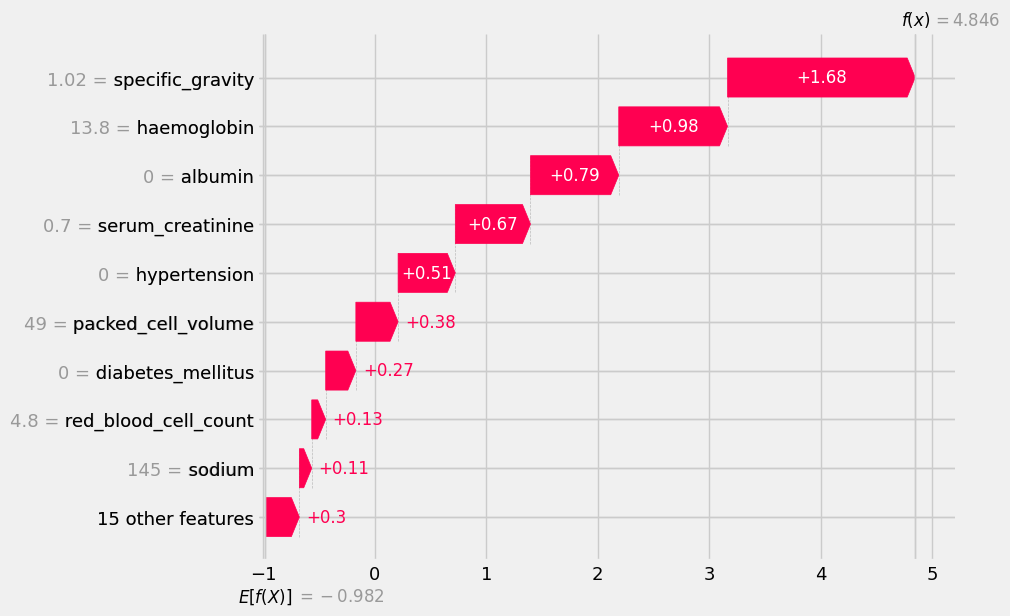

In [ ]:
# SHAP waterfall plot for the 5th instance in the dataset
shap.plots.waterfall(shap_values[4])



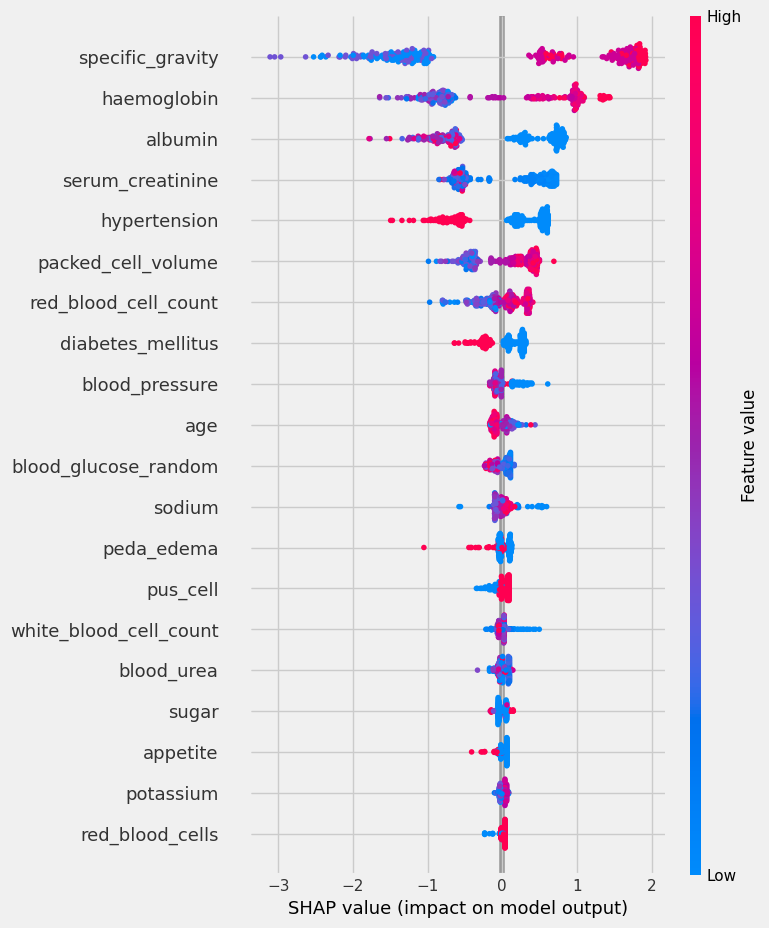

In [ ]:
# SHAP summary plot for feature importance
shap.summary_plot(shap_values, X_train)

f(X)=predicted probability of the particular instance
if +ve strongly predict ckd
-ve strongly predict no ckd

E[f(X)]=avg prediction for entire dataset



# **Computing the Mean of the shap values to find the contributions of each features in predicting the output**

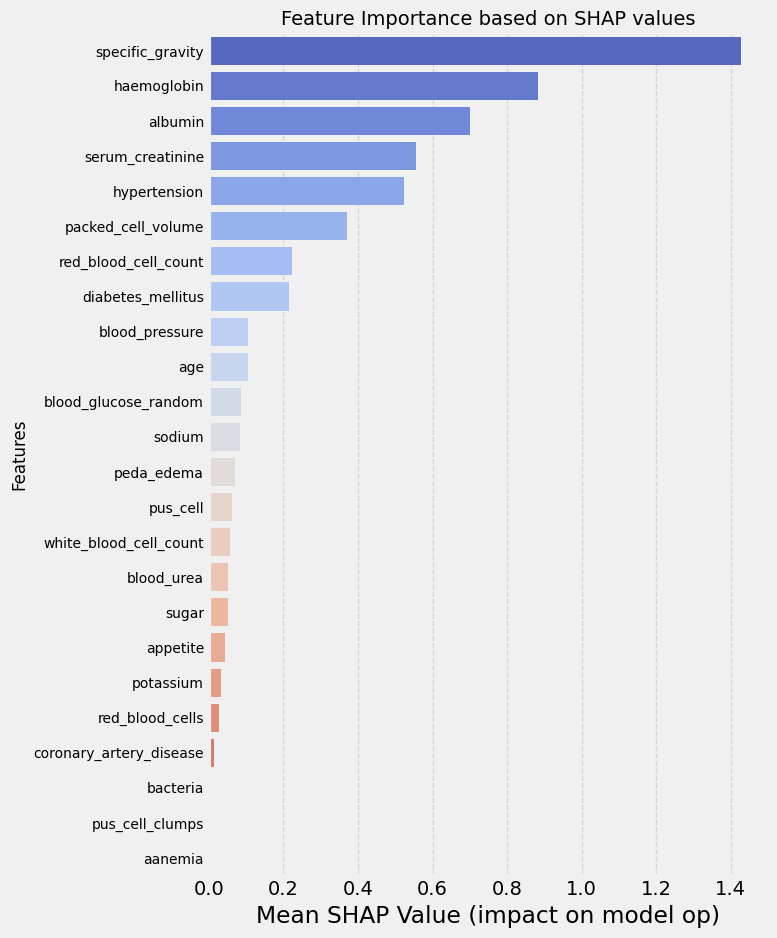

In [ ]:
mean_shap_values=np.mean(np.abs(shap_values.values),axis=0)
sorted_idx=np.argsort(mean_shap_values)[::-1]
plt.figure(figsize=(8,len(x.columns)*0.4))
sns.barplot(x=mean_shap_values[sorted_idx],y=x.columns[sorted_idx],palette='coolwarm')
plt.xlabel('Mean SHAP Value (impact on model op)')
plt.ylabel('Features',fontsize=12)
plt.title('Feature Importance based on SHAP values',fontsize=14)
plt.yticks(fontsize=10)
plt.grid(True,axis='x',linestyle='--',alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:

import lime
import lime.lime_tabular

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the SVM model
svm_model = SVC(kernel='linear', probability=True, random_state=42)  # Enable probability for LIME
svm_model.fit(X_train_scaled, Y_train)



# Initialize LIME Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(X_train_scaled, feature_names=x.columns,
                                                   class_names=['No CKD', 'CKD'],
                                                   verbose=True, mode='classification')

# Choose an instance to explain (e.g., the first instance in the test set)
i = 7 # First instance
exp = explainer.explain_instance(X_test_scaled[i], svm_model.predict_proba, num_features=5)

# Show explanation
exp.show_in_notebook(show_table=True)

# You can also save it as an HTML file to view in a browser
exp.save_to_file('lime_explanation.html')


Intercept -0.021377828528663705
Prediction_local [0.04288189]
Right: 0.9254057758809803


In [ ]:
!pip install pennylane pennylane-qiskit qiskit catboost


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
import pennylane as qml
import numpy as np
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

# Step 1: Train a CatBoost model for initial feature importance
catboost_model = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, verbose=0)
catboost_model.fit(X_train, Y_train)

# Step 2: Get feature importances and select the top k features
importances = catboost_model.get_feature_importance()
k = 15  # Number of top features to select
top_features_idx = np.argsort(importances)[-k:]

# Select top features for training a quantum model
X_train_selected = X_train.iloc[:, top_features_idx]
X_test_selected = X_test.iloc[:, top_features_idx]

# Step 3: Define and train a simple quantum model
n_qubits = X_train_selected.shape[1]  # Number of selected features
params = np.random.rand(n_qubits)

dev = qml.device("default.qubit", wires=n_qubits)
#applying quantum features
@qml.qnode(dev)
def quantum_circuit(params):
    for i in range(n_qubits):
        qml.RY(params[i], wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

def quantum_feature_selector(params, X):
    selected_features = []
    for x in X:
        encoding = quantum_circuit(params)  # Get numerical results from the quantum circuit
        selected_features.append(x * encoding)  # Element-wise multiplication
    return np.array(selected_features)

# Scale your selected features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

# Prepare quantum-enhanced features for CatBoost
X_train_quantum = quantum_feature_selector(params, X_train_scaled)
X_test_quantum = quantum_feature_selector(params, X_test_scaled)

# Step 4: Train CatBoost on quantum-enhanced features
quantum_catboost_model = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, verbose=0)
quantum_catboost_model.fit(X_train_quantum, Y_train)

# Evaluate the quantum-enhanced CatBoost model
quantum_predictions = quantum_catboost_model.predict(X_test_quantum)
accuracy = accuracy_score(Y_test, quantum_predictions)

print(f"Improved Accuracy of the CatBoost Model with Quantum Features: {accuracy * 100:.2f}%")


Improved Accuracy of the CatBoost Model with Quantum Features: 99.17%


In [ ]:
px.bar(data_frame = tot_models, x = 'Accuracy', y = 'Model', color = 'Accuracy', template = 'plotly_white',
       title = 'Models Comparison', category_orders={'Model': tot_models['Model'].tolist()})

In [ ]:
tot_models=pd.DataFrame({
    'Model':['Logistic_Regression','CatBoost Classsifier','SVM','Naive Bayes','Quantum Boosted Algorithm'],
    'Accuracy':[lg_acc,cat_acc,svm_acc,naive_bayes_acc,accuracy]
})
tot_models=tot_models.sort_values(by='Accuracy',ascending=False)
tot_models


,Model,Accuracy
4,Quantum Boosted Algorithm,0.991667
1,CatBoost Classsifier,0.983333
2,SVM,0.958333
3,Naive Bayes,0.925000
0,Logistic_Regression,0.750000
